# Dysmark Demo: Практические сценарии использования

Этот ноутбук демонстрирует три прикладных сценария использования библиотеки `dysmark` для анализа детской речи:

1.  **Тренажер скороговорок:** Интерактивная проверка произношения с обратной связью.
2.  **Мониторинг прогресса терапии:** Визуализация динамики улучшения речи (сравнение сеансов).
3.  **Фонетический микроскоп:** Детальный разбор конкретных ошибок в слове/фразе.

**Примечание:** Для работы требуется наличие модели `dysata/Wav2Vec2-Ru-Child` и установленных зависимостей. Если у вас нет реальных `.wav` файлов для теста, ноутбук может работать в режиме симуляции (демо-данные).

## 0. Настройка окружения

In [1]:
import sys
import os
import json
import random
from pathlib import Path
from collections import Counter

# Добавляем путь к модулям
sys.path.insert(0, '../model')

# Импорт наших модулей
try:
    import dysmarkccls_clean as dysmark
    MODEL_AVAILABLE = True
except ImportError:
    print("Warning: dysmark module not found. Running in SIMULATION mode.")
    MODEL_AVAILABLE = False

# Библиотеки для визуализации
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Audio, display, Markdown

sns.set(style="whitegrid", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 6)

print("Environment ready.")

Environment ready.


---
## Сценарий 1: Тренажер скороговорок

**Цель:** Ребенок читает скороговорку, система оценивает чистоту речи, находит ошибки и дает рекомендации.

**Логика:**
1. Выбираем скороговорку.
2. (Симуляция) Загружаем аудио или генерируем мок-результат.
3. Анализируем маркеры.
4. Вычисляем "Индекс Чистоты" (100% - доля ошибок).
5. Выводим конкретные проблемные места.

In [2]:
def run_tongue_twister_challenge(reference_text, audio_path=None, use_simulation=False):
    """
    Analyzes pronunciation of a tongue twister.
    """
    print(f"\nСкороговорка: \"{reference_text}\"")
    
    if use_simulation or not MODEL_AVAILABLE or audio_path is None:
        print("Режим симуляции (нет аудио или модели). Генерируем демо-результат...")
        # Симуляция ошибок для демонстрации
        # Представим, что ребенок сказал: "Шла Саша по шосссе и сосала сушку" (заикание на с, замена ш->с)
        mock_data = []
        words = reference_text.split()
        for w in words:
            for char in w:
                # Симулируем ошибку с вероятностью 30%
                if random.random() < 0.3 and char in ['ш', 'с', 'щ']:
                    hyp_char = 'с' if char == 'ш' else 'ш'
                    mark = '7' if random.random() > 0.5 else 'C'
                elif random.random() < 0.1 and char in ['к', 'т']:
                    hyp_char = char + char # Имитация заикания будет обработана отдельно в логике, тут упростим
                    mark = 'K'
                    hyp_char = char
                else:
                    hyp_char = char
                    mark = '0'
                mock_data.append([char, hyp_char, mark])
        result = {'triples': mock_data, 'quality': 'good'}
    else:
        # Реальный вызов библиотеки
        result = dysmark.get_markers(reference_text, audio_path)
        if result['quality'] == 'bad':
            print(f"Ошибка качества аудио: {result.get('problem')}")
            return

    triples = result['triples']
    
    # Анализ статистики
    total_chars = len(triples)
    errors = [t for t in triples if t[2] != '0']
    error_count = len(errors)
    purity_score = ((total_chars - error_count) / total_chars) * 100 if total_chars > 0 else 0
    
    # Подсчет типов ошибок
    error_types = Counter()
    for _, _, mark in errors:
        for m in mark: # На случай составных маркеров
            error_types[m] += 1

    # Вывод отчета
    print("\n" + "="*60)
    print(f"РЕЗУЛЬТАТЫ ПРОИЗНОШЕНИЯ")
    print("="*60)
    print(f"Индекс чистоты речи: {purity_score:.1f}%")
    print(f"Всего ошибок: {error_count} из {total_chars} символов")
    
    if error_types:
        print("\nСтруктура ошибок:")
        marker_names = {
            'K': 'Заикание', '7': 'Оглушение/Озвончение', 'C': 'Произвольная замена',
            'B': 'Пропуск гласной', 'L': 'Удлинение согласной', 'A': 'Удлинение гласной',
            'D': 'Перестановка гласных', 'E': 'Перестановка согласных'
        }
        for code, count in error_types.most_common():
            name = marker_names.get(code, f'Тип {code}')
            print(f"   - {name} ({code}): {count} раз")
        
        # Рекомендации
        print("\nРекомендации:")
        if 'K' in error_types:
            print(" - Обратите внимание на плавность речи. Попробуйте проговаривать фразу медленнее, нараспев.")
        if '7' in error_types:
            print(" - Тренируйте различение звонких и глухих согласных. Упражнение 'Парочки'.")
        if 'B' in error_types or 'L' in error_types:
            print(" - Следите за четкостью окончаний и проговариванием всех гласных.")
    else:
        print("\nОтличная работа! Ошибок не обнаружено.")

    # Детальный просмотр (первые 5 ошибок)
    if errors:
        print("\nПримеры ошибок (первые 5):")
        df_errors = pd.DataFrame(errors[:5], columns=['Эталон', 'Распознано', 'Код'])
        display(df_errors)

# Запуск сценария 1
twister = "Шла Саша по шоссе и сосала сушку"
# Если есть файл: run_tongue_twister_challenge(twister, audio_path='path/to/audio.wav')
run_tongue_twister_challenge(twister, use_simulation=True)


Скороговорка: "Шла Саша по шоссе и сосала сушку"
Режим симуляции (нет аудио или модели). Генерируем демо-результат...

РЕЗУЛЬТАТЫ ПРОИЗНОШЕНИЯ
Индекс чистоты речи: 92.3%
Всего ошибок: 2 из 26 символов

Структура ошибок:
   - Произвольная замена (C): 2 раз

Рекомендации:

Примеры ошибок (первые 5):


,Эталон,Распознано,Код
0,с,ш,C
1,с,ш,C


---
## Сценарий 2: Мониторинг прогресса терапии

**Цель:** Показать родителям и врачу динамику улучшения речи за несколько сеансов.

**Логика:**
1. Создаем синтетические данные за 4 недели (или используем реальные файлы Session1..Session4).
2. Считаем количество ошибок каждого типа для каждой сессии.
3. Строим график спада ошибок.


Анализ динамики лечения...


<Figure size 1400x700 with 0 Axes>

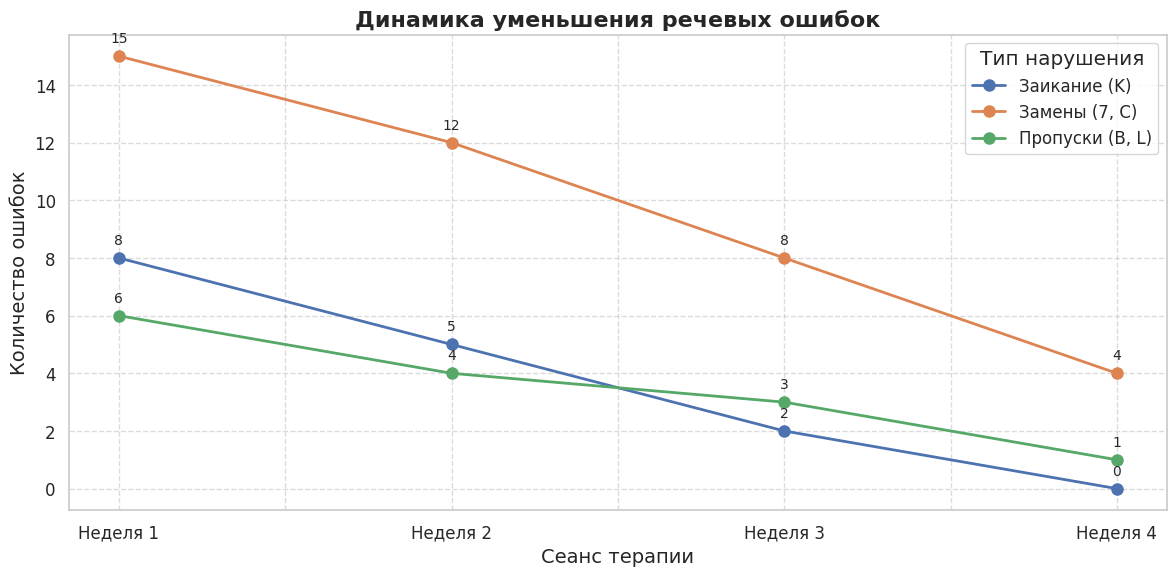


Общий прогресс: Снижение количества ошибок на 82.8%
   Было ошибок: 29, Стало: 5


In [3]:
def plot_therapy_progress(simulate=True):
    """
    Visualizes speech improvement over multiple sessions.
    """
    print("\nАнализ динамики лечения...")

    sessions = ["Неделя 1", "Неделя 2", "Неделя 3", "Неделя 4"]
    
    # Данные для графика 
    if simulate:
        # Симуляция улучшения: ошибки уменьшаются
        data = {
            'Заикание (K)': [8, 5, 2, 0],
            'Замены (7, C)': [15, 12, 8, 4],
            'Пропуски (B, L)': [6, 4, 3, 1]
        }
    else:
        # Здесь должна быть логика загрузки реальных файлов
        # цикл по файлам и вызов dysmark.get_markers()
        # data = analyze_real_sessions(['session1.wav', 'session2.wav', ...])
        data = {'Заикание (K)': [], 'Замены (7, C)': [], 'Пропуски (B, L)': []}

    df_progress = pd.DataFrame(data, index=sessions)

    # Построение графика
    plt.figure(figsize=(14, 7))
    ax = df_progress.plot(marker='o', linewidth=2, markersize=8, fontsize=12)
    
    plt.title('Динамика уменьшения речевых ошибок', fontsize=16, fontweight='bold')
    plt.xlabel('Сеанс терапии', fontsize=14)
    plt.ylabel('Количество ошибок', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='Тип нарушения', fontsize=12)
    
    # Аннотации на точках
    for line in ax.lines:
        for x, y in zip(line.get_xdata(), line.get_ydata()):
            ax.annotate(f'{int(y)}', xy=(x, y), textcoords="offset points", xytext=(0,10), ha='center', fontsize=10)

    plt.tight_layout()
    plt.show()

    # Вывод итоговой статистики
    total_start = sum(df_progress.iloc[0])
    total_end = sum(df_progress.iloc[-1])
    improvement = ((total_start - total_end) / total_start * 100) if total_start > 0 else 0
    
    print(f"\nОбщий прогресс: Снижение количества ошибок на {improvement:.1f}%")
    print(f"   Было ошибок: {total_start}, Стало: {total_end}")

# Запуск сценария 2
plot_therapy_progress(simulate=True)

---
## Сценарий 3: Фонетический микроскоп

**Цель:** Детальный разбор одной фразы для логопеда. Показывает не просто факт ошибки, а её контекст и тип.

**Логика:**
1. Берем фразу с известными сложностями.
2. Получаем полную таблицу выравнивания.
3. Визуализируем "Heatmap" ошибок.


Фонетический разбор фразы: "молоко шкаф дом"

Таблица посимвольного сравнения:
(Зеленый = ОК, Желтый = Замена, Красный = Заикание, Синий = Перестановка)


,Ref,Hyp,Mark
0,м,м,0
1,о,о,0
2,л,л,0
3,о,о,0
4,к,к,0
5,о,о,0
6,|,|,0
7,ш,с,7
8,к,к,0
9,а,а,0


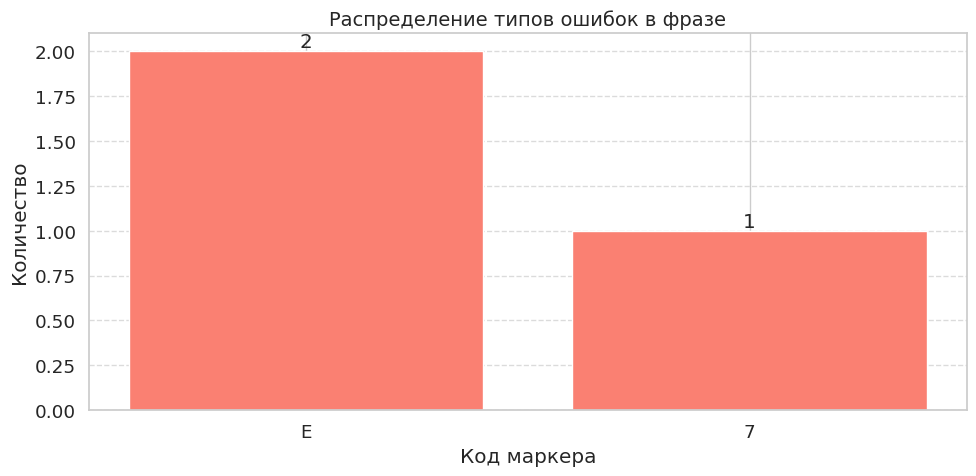

In [8]:
def phonetic_microscope(reference_text, use_simulation=True):
    """
    Detailed character-level analysis with visualization.
    """
    print(f"\nФонетический разбор фразы: \"{reference_text}\"")

    if use_simulation or not MODEL_AVAILABLE:
        # Симуляция сложного случая: перестановки и замены
        mock_triples = [
            ['м', 'м', '0'], ['о', 'о', '0'], ['л', 'л', '0'], ['о', 'о', '0'], 
            ['к', 'к', '0'], ['о', 'о', '0'], 
            ['|', '|', '0'],
            ['ш', 'с', '7'], ['к', 'к', '0'], ['а', 'а', '0'], ['ф', 'ф', '0'],
            ['|', '|', '0'],
            ['д', 'м', 'E'], ['о', 'о', '0'], ['м', 'д', 'E'] 
        ]
        result = {'triples': mock_triples, 'quality': 'good'}
    else:
        return print("Требуется аудиофайл для реального режима.")

    triples = result['triples']
    df = pd.DataFrame(triples, columns=['Ref', 'Hyp', 'Mark'])
    
    # Функция для цветного отображения
    def color_code(mark):
        if mark == '0': return 'background-color: #d4edda; color: #155724' # Green
        if mark in ['K', 'J']: return 'background-color: #f8d7da; color: #721c24; font-weight: bold' # Red
        if mark in ['7', '1', '2', '3', '4', '5', '6', '8', 'G']: return 'background-color: #fff3cd; color: #856404' # Yellow
        if mark in ['D', 'E']: return 'background-color: #d1ecf1; color: #0c5460' # Blue
        return 'background-color: #f5f5f5'

    # ИСПРАВЛЕНИЕ: используем .map() вместо устаревшего .applymap()
    try:
        styled_df = df.style.map(color_code, subset=['Mark']).set_properties(**{'text-align': 'center'})
    except AttributeError:
        # Фоллбэк для очень старых версий pandas (если вдруг запустится на старом сервере)
        styled_df = df.style.applymap(color_code, subset=['Mark']).set_properties(**{'text-align': 'center'})
    
    print("\nТаблица посимвольного сравнения:")
    print("(Зеленый = ОК, Желтый = Замена, Красный = Заикание, Синий = Перестановка)")
    display(styled_df)

    # Визуализация распределения ошибок по типам
    error_counts = df[df['Mark'] != '0']['Mark'].value_counts()
    
    if not error_counts.empty:
        plt.figure(figsize=(10, 5))
        bars = plt.bar(error_counts.index, error_counts.values, color='salmon')
        plt.title('Распределение типов ошибок в фразе', fontsize=14)
        plt.xlabel('Код маркера')
        plt.ylabel('Количество')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                     f'{int(height)}', ha='center', va='bottom')
        plt.tight_layout()
        plt.show()
    else:
        print("\nОшибок в данной фразе не обнаружено.")

# Запуск сценария 3
phrase = "молоко шкаф дом"
phonetic_microscope(phrase, use_simulation=True)

---
## Заключение

В этом ноутбуке продемонстрированы варианты применения модели анализа аудиозаписей на предмет выявления признаков-маркеров дислексии для построения различных приложений:
1.  **Геймификация обучения/тренировок:** Обратная связь для ребенка (Сценарий 1).
2.  **Отчетность о прогрессе терапии:** Наглядные графики для родителей и врачей (Сценарий 2).
3.  **Диагностика:** Глубокий анализ для специалиста (Сценарий 3).